# HuggingFace Debug Notebook
Step through each cell to isolate what's failing.

In [1]:
# 1. Load token from .env
from dotenv import load_dotenv
import os

load_dotenv()
token = os.environ.get("HF_TOKEN", "")
print(f"Token loaded: {'yes' if token else 'NO — HF_TOKEN not set'}")
print(f"Token preview: {token[:8]}...{token[-4:] if len(token) > 12 else '(too short)'}")

Token loaded: yes
Token preview: hf_QoUDF...bhjA


In [2]:
# 2. Verify token is valid via the HF whoami endpoint
import requests

resp = requests.get(
    "https://huggingface.co/api/whoami-v2",
    headers={"Authorization": f"Bearer {token}"},
)
print(f"Status: {resp.status_code}")
if resp.ok:
    data = resp.json()
    print(f"Logged in as: {data.get('name')} ({data.get('email', 'no email')}")
else:
    print(f"Error: {resp.text}")

Status: 200
Logged in as: Code780 (no email


In [3]:
# 3. Check token scopes (need 'inference.serverless.write' for Inference API)
import requests

resp = requests.get(
    "https://huggingface.co/api/whoami-v2",
    headers={"Authorization": f"Bearer {token}"},
)
if resp.ok:
    auth = resp.json().get("auth", {})
    access_token = auth.get("accessToken", {})
    scopes = access_token.get("fineGrained", {}).get("scoped", [])
    role = access_token.get("role", "unknown")
    print(f"Token role: {role}")
    print(f"Scopes: {scopes if scopes else '(none — may be a legacy full-access token)'}")
else:
    print("Couldn't fetch scopes — token invalid")

Token role: fineGrained
Scopes: [{'entity': {'_id': '69e988f409ee078b89183190', 'type': 'user', 'name': 'Code780'}, 'permissions': ['inference.serverless.write']}]


In [4]:
# 4. Try InferenceClient with nscale provider (same as app.py)
from huggingface_hub import InferenceClient

client = InferenceClient(provider="nscale", api_key=token)
print("Client created — attempting text_to_image with FLUX.1-schnell...")

try:
    image = client.text_to_image("a red apple on a white table", model="black-forest-labs/FLUX.1-schnell")
    print(f"Success! Image size: {image.size}")
    image
except Exception as e:
    print(f"Failed: {type(e).__name__}: {e}")

Our latest automated health check on model 'black-forest-labs/FLUX.1-schnell' for provider 'nscale' did not complete successfully.  Inference call might fail.


Client created — attempting text_to_image with FLUX.1-schnell...
Failed: HfHubHTTPError: Client error '401 Unauthorized' for url 'https://router.huggingface.co/nscale/v1/images/generations' (Request ID: Root=1-69fbe6df-01e436fe3bb9a4f03bdbff46;c50959d4-36eb-4d21-aae8-e86c36ae2a52)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

{'code': '401', 'message': 'Invalid or expired token', 'param': None, 'type': 'UNAUTHORIZED'}


In [5]:
# 5. Fallback: try without specifying a provider (uses HF's default routing)
from huggingface_hub import InferenceClient

client_default = InferenceClient(api_key=token)
print("Trying without provider='nscale'...")

try:
    image = client_default.text_to_image("a red apple on a white table", model="black-forest-labs/FLUX.1-schnell")
    print(f"Success! Image size: {image.size}")
    image
except Exception as e:
    print(f"Failed: {type(e).__name__}: {e}")

Trying without provider='nscale'...
Success! Image size: (1024, 768)


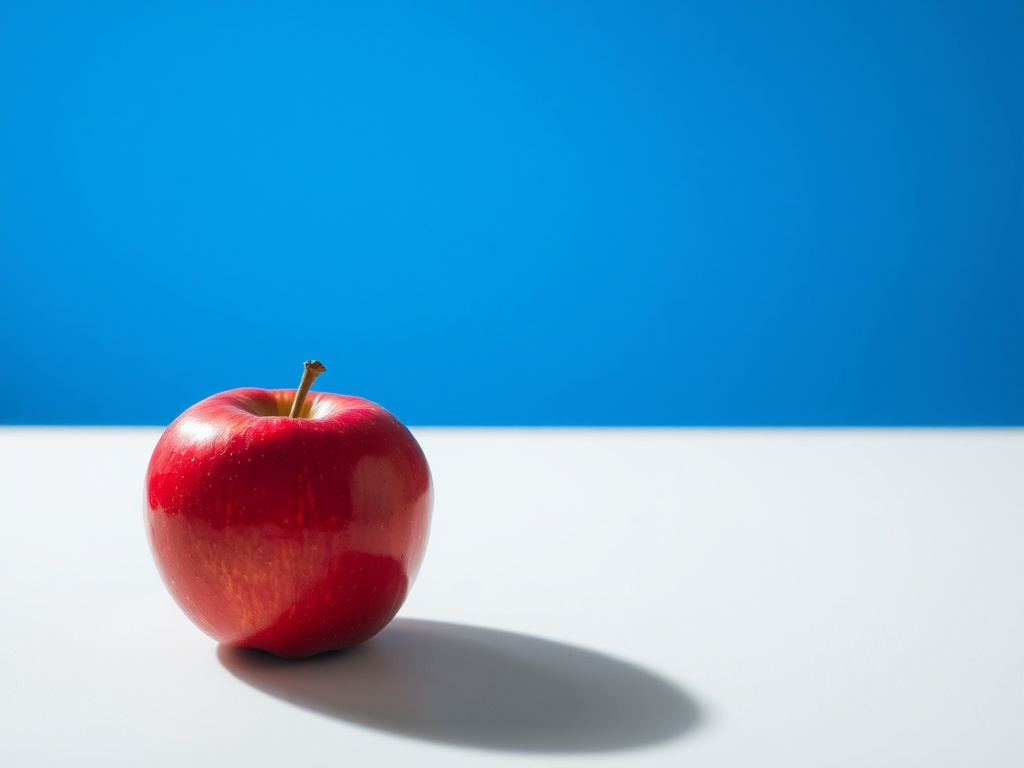

In [6]:
image